# Öneri Sistemleri

Öneri sistemleri, kullanıcıların geçmiş tercihlerine dayanarak onlara ürünler önermek için kullanılır. Öneri sistemleri genel olarak aşağıdaki kategorilere ayrılır:

- **İçerik tabanlı (Content-based)**: Ürün özelliklerinin (ör. anahtar kelimeler, kategoriler) ve kullanıcı tercihlerinin benzerliğine dayanır.  
  Örneğin, bir kullanıcı Ürün A’yı beğendiyse, öneri sistemi benzer özelliklere sahip ürünleri önerir. Filmler üzerinden konuşursak, bu özellikler yapımcı, tür vb. olabilir. Genellikle bu yaklaşım, denetimli bir ikili sınıflandırma algoritması ile uygulanabilir.

- **İşbirlikçi filtreleme (Collaborative filtering)**: Benzerliği kullanıcı–ürün etkileşimlerinden (ör. puanlar, satın alma sayısı, beğeniler vb.) hesaplar.  
  Bu yöntem, benzer tercihlere sahip müşterileri bulur ve ardından bir müşteriye, onun henüz deneyimlemediği fakat benzer profildeki diğer müşteriler tarafından tercih edilen ürünleri önerir. Sistem, benzer film izleme alışkanlıklarına sahip kullanıcıların genel olarak benzer tercihlere sahip olduğu varsayımını yapar. Kullanıcının izlediklerine benzer videolar izleyen diğer kullanıcıları bulur, ardından bu kullanıcıların izlediği fakat ilk kullanıcının henüz izlemediği videoları önerir. Bu yaklaşımın 3 türü vardır: kullanıcı–kullanıcı işbirlikçi filtreleme, ürün–ürün işbirlikçi filtreleme ve matris çarpanlarına ayırma (matrix factorization).

- Daha yeni ve genellikle daha güçlü yaklaşımlar ise **Hibrit sistemlerdir (Hybrid systems)**.  
  Bu sistemler, yukarıda bahsedilen iki yöntemi birleştirir.

<img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/05-ML/06-Unsupervised-Learning/recommendation_systems.png" width=600>

Yukarıdaki diyagram, bir öneri sistemi oluşturmak için kullanılan farklı metodolojileri detaylı bir şekilde sınıflandırmaktadır.

Daha sonra örnek veri seti olarak kullanılacak olan `movieLens` bağlamında:
- İçerik benzerliğine (ör. tür, oyuncu kadrosu vb.) dayalı olarak farklı filmler önerebiliriz; bu durumda **ürün-içerik (item-content) filtreleme** uygulanır.
- Kullanıcı meta verilerini (ör. yaş, cinsiyet) karşılaştırarak, benzer kullanıcıların beğendiği ürünleri bir kullanıcıya önerebiliriz; bu durumda **kullanıcı-içerik (user-content) filtreleme** kullanılır. Ancak `movieLens` veri seti kullanıcı içerik verilerini içermediği için, yalnızca **ürün-ürün (item-item) işbirlikçi filtreleme** oluşturacağız.

**Bellek tabanlı (Memory-based) içerik filtreleme**

Bellek tabanlı yöntemlerde, veriden öğrenip tahmin yapan bir model yoktur. Bunun yerine, film önerileri için kullanılabilecek **önceden hesaplanmış bir benzerlik matrisi** oluşturulur.

## Veri toplama ve temizleme

Aşağıdaki satırları çalıştırarak gerekli veri kümelerini indirin. Ardından, veri kümelerini üç farklı pandas DataFrame'e (`movies`, `tags` ve `ratings`) yükleyin.

In [1]:
!curl https://d32aokrjazspmn.cloudfront.net/materials/movie_ratings.csv > data/movies.csv
!curl https://d32aokrjazspmn.cloudfront.net/materials/movie_tags.csv > data/tags.csv
!curl https://d32aokrjazspmn.cloudfront.net/materials/movie_titles.csv > data/ratings.csv

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed

  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
  1 2425k    1 32768    0     0  73958      0  0:00:33 --:--:--  0:00:33 74135
100 2425k  100 2425k    0     0  4204k      0 --:--:-- --:--:-- --:--:-- 4210k
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed

  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100  115k  100  115k    0     0   366k      0 --:--:-- --:--:-- --:--:--  367k
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed

  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100  482k  100  482k    0     0  1245k      0 --:

In [2]:
import pandas as pd

movies = pd.read_csv("data/ratings.csv")   
tags = pd.read_csv("data/tags.csv")
ratings = pd.read_csv("data/movies.csv")

In [3]:
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [4]:
tags.head()

,userId,movieId,tag,timestamp
0,2,60756,funny,1445714994
1,2,60756,Highly quotable,1445714996
2,2,60756,will ferrell,1445714992
3,2,89774,Boxing story,1445715207
4,2,89774,MMA,1445715200


In [5]:
ratings.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


__Farklı film türlerini ayıran ‘|’ işaretini kaldırın ve boşluk ile değiştirin.__

In [6]:
movies["genres"] = movies["genres"].str.replace("|", " ", regex=False)

__`movies` veri çerçevesini filtreleyerek, yalnızca puan almış filmleri elde edin.__

In [7]:
rated_movie_ids = ratings["movieId"].unique()

movies = movies[movies["movieId"].isin(rated_movie_ids)]

### 🧪 Kodunu Test Et

In [8]:
from nbresult import ChallengeResult

result = ChallengeResult(
    'datasets',
    movies_shape=movies.shape,
    tags_shape=tags.shape,
    ratings_shape=ratings.shape,
    genres_cleaned=movies['genres'].str.find('|') >= 0
)

result.write()
print(result.check())


============================= test session starts =============================
platform win32 -- Python 3.11.7, pytest-9.0.2, pluggy-1.6.0 -- C:\Users\meaki\AppData\Local\Programs\Python\Python311\python.exe
cachedir: .pytest_cache
rootdir: C:\Users\meaki\Desktop\Fraud Detection Using ML\Fraud-Detection-Analysis\S17D3-S-data-movie-recommendation\tests
plugins: anyio-4.12.0, dash-4.0.0
collecting ... collected 4 items

test_datasets.py::TestDatasets::test_genres_are_cleaned PASSED           [ 25%]
test_datasets.py::TestDatasets::test_movies_shape PASSED                 [ 50%]
test_datasets.py::TestDatasets::test_ratings_shape PASSED                [ 75%]
test_datasets.py::TestDatasets::test_tags_shape PASSED                   [100%]

============================== 4 passed in 0.27s ==============================


💯 You can commit your code:

git add tests/datasets.pickle

git commit -m 'Completed datasets step'

git push origin master



## Özellik Mühendisliği

Bir film hakkında sahip olduğumuz **tüm metin verisi bilgilerini**, yani türü ve etiketleri birleştiren `metadata` adlı yeni bir özellik oluşturacağız.

__`movies` ve `tags` DataFrame'lerini birleştirin.__

In [10]:
tags_grouped = tags.groupby("movieId")["tag"].apply(lambda x: " ".join(x.astype(str)))

**`metadata` sütununu içeren yeni bir `merged_df` veri çerçevesi oluşturun. Bu sütun, hem etiketlerin (tags) hem de türlerin (genres) birleştirilmiş hâlinden oluşmalıdır.**

Bunun için:
- Önce **etiketleri (tags)** film bazında birleştirin.
- Ardından bu birleştirilmiş etiketleri **genres** sütunu ile birleştirin.

Örneğin *Toy Story* filminin `metadata` sütunu şu şekilde olmalıdır:  
`pixar pixar fun Adventure Animation Children Comedy Fantasy`

👉 `merged_df` en azından şu sütunları içermelidir: `movieId`, `title` ve `metadata`.

In [11]:
merged_df = movies.merge(tags_grouped, on="movieId", how="left")
merged_df["tag"] = merged_df["tag"].fillna("")
merged_df["metadata"] = merged_df["genres"] + " " + merged_df["tag"]
merged_df = merged_df[["movieId", "title", "metadata"]]

### 🧪 Kodunu Test Et

In [12]:
from nbresult import ChallengeResult
import numpy as np

result = ChallengeResult(
    'feature_engineering',
    unique_movies=np.all(merged_df[['movieId']].value_counts() > 1),
    metadata=merged_df[merged_df['title'] == 'Copycat (1995)'],
    merged_df_rows=merged_df.shape[0]
)

result.write()
print(result.check())


============================= test session starts =============================
platform win32 -- Python 3.11.7, pytest-9.0.2, pluggy-1.6.0 -- C:\Users\meaki\AppData\Local\Programs\Python\Python311\python.exe
cachedir: .pytest_cache
rootdir: C:\Users\meaki\Desktop\Fraud Detection Using ML\Fraud-Detection-Analysis\S17D3-S-data-movie-recommendation\tests
plugins: anyio-4.12.0, dash-4.0.0
collecting ... collected 4 items

test_feature_engineering.py::TestFeatureEngineering::test_merged_df_rows PASSED [ 25%]
test_feature_engineering.py::TestFeatureEngineering::test_metadata_has_genres PASSED [ 50%]
test_feature_engineering.py::TestFeatureEngineering::test_metadata_has_tags PASSED [ 75%]
test_feature_engineering.py::TestFeatureEngineering::test_unicity_of_movies PASSED [100%]

============================== 4 passed in 0.72s ==============================


💯 You can commit your code:

git add tests/feature_engineering.pickle

git commit -m 'Completed feature_engineering step'

git push or

## Metadata’dan içerik gizil (latent) matrisi oluşturma

### Count Vectorizer

Bir sonraki adımda, metadata metinlerini vektörlere dönüştürmemiz gerekiyor; böylece bunları makine öğrenmesi algoritmalarına verebiliriz. Makine öğrenmesi modelleri metin verisini doğrudan anlayamaz, bu yüzden kodlamamız gerekir.

Bu amaçla [`CountVectorizer`](https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.CountVectorizer.html) kullanarak `metadata` sütununu encode edeceğiz.

Count dönüşümü sonucunda elde ettiğiniz vektörlerden oluşan yeni bir `count_df` veri çerçevesi oluşturun.  
Her satır, ilgili filme ait **frekans vektörünü** temsil edecektir.

In [13]:
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd
vectorizer = CountVectorizer()
count_matrix = vectorizer.fit_transform(merged_df["metadata"])
count_df = pd.DataFrame(
    count_matrix.toarray(),
    columns=vectorizer.get_feature_names_out()
)
count_df.index = merged_df["movieId"]

### Boyut indirgeme

Her bir filmin metadata’sı yaklaşık **1675 uzunluğunda bir vektöre** dönüştürüldü!

Önceki derslerde gördüğümüz gibi, veriyi (filmleri) çok fazla bilgi kaybı olmadan temsil edebilmek için **boyut indirgeme** yöntemleri uygulayabiliriz. **Truncated Singular Value Decomposition (SVD)**, boyut indirgeme için kullanılan başka bir gelişmiş araçtır.

PCA’nın aksine, bu yöntem **tekil değer ayrışımını (SVD) hesaplamadan önce veriyi merkezlemez**. Bu da onun **seyrek (sparse) matrislerle verimli şekilde çalışabilmesini** sağlar. Özellikle terim sayım / frekans matrisleri üzerinde iyi çalışır. Bu bağlamda, **Latent Semantic Analysis (LSA)** olarak da bilinir.

Scikit-Learn’deki [`TruncatedSVD`](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.TruncatedSVD.html) sınıfına göz atabilirsiniz; prensip olarak PCA ile aynıdır.

__👉 **Count matrinizin boyutunu azaltmak için (örneğin 25 feature olacak şekilde) Truncated SVD uygulayın.**__


In [14]:
from sklearn.decomposition import TruncatedSVD

svd = TruncatedSVD(n_components=25, random_state=42)

latent_matrix = svd.fit_transform(count_matrix)

👉 **Toplam açıklanan varyans oranını bileşen sayısının bir fonksiyonu olarak grafiğe çizin.**

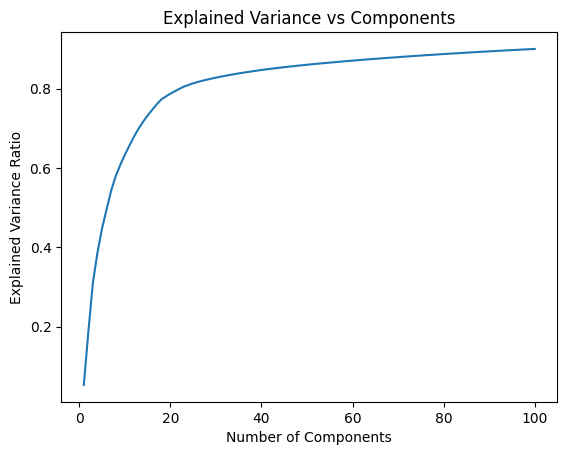

In [15]:
import matplotlib.pyplot as plt
import numpy as np

components = list(range(1, 101))
explained_variance = []

for n in components:
    svd_temp = TruncatedSVD(n_components=n, random_state=42)
    svd_temp.fit(count_matrix)
    explained_variance.append(svd_temp.explained_variance_ratio_.sum())

plt.plot(components, explained_variance)
plt.xlabel("Number of Components")
plt.ylabel("Explained Variance Ratio")
plt.title("Explained Variance vs Components")
plt.show()

Sadece ilk 25 bileşenle (başlangıçta yaklaşık 1700 olan) varyansın **%80'inden fazlasını** açıklayabildiğimizi görüyoruz, bu da çalışma amaçlarımız için yeterlidir.

👉 **Bu matrisin 25 bileşenini, filmlerin başlıklarına göre indekslenmiş yeni bir `latent_df` veri çerçevesine kaydedin.**

In [16]:
latent_df = pd.DataFrame(
    latent_matrix,
    index=merged_df["title"],
    columns=[f"component_{i}" for i in range(25)]
)

### 🧪 Kodunu Test Et

In [17]:
from nbresult import ChallengeResult

result =  ChallengeResult(
    'metadata',
    counter_shape=count_df.shape,
    latent_shape=latent_df.shape
)

result.write()
print(result.check())


============================= test session starts =============================
platform win32 -- Python 3.11.7, pytest-9.0.2, pluggy-1.6.0 -- C:\Users\meaki\AppData\Local\Programs\Python\Python311\python.exe
cachedir: .pytest_cache
rootdir: C:\Users\meaki\Desktop\Fraud Detection Using ML\Fraud-Detection-Analysis\S17D3-S-data-movie-recommendation\tests
plugins: anyio-4.12.0, dash-4.0.0
collecting ... collected 3 items

test_metadata.py::TestMetadata::test_counter_columns PASSED              [ 33%]
test_metadata.py::TestMetadata::test_counter_rows PASSED                 [ 66%]
test_metadata.py::TestMetadata::test_features_number PASSED              [100%]

============================== 3 passed in 0.04s ==============================


💯 You can commit your code:

git add tests/metadata.pickle

git commit -m 'Completed metadata step'

git push origin master



## Kullanıcı Derecelendirmelerinden Latent Matris Oluşturma

Meta veriler dışında, bir başka değerli bilgi kaynağımız daha var: **kullanıcı derecelendirmeleri**. 

Bir öneri sistemi, kullanıcı derecelendirmelerine dayanarak benzer bir film önerebilir (öğeden öğeye işbirliğine dayalı filtreleme).

👉 **Aşağıdaki veri setini, filmleri satırlara, `userId`'leri sütunlara yerleştirecek şekilde hazırlıyoruz.**

In [19]:
# Merge
ratings1 = pd.merge(movies[['movieId']], ratings, on="movieId", how="right")
# Pivot
ratings2 = ratings1.pivot(index = 'movieId', columns ='userId', values = 'rating').fillna(0)
display(ratings2.head())
ratings2.shape

userId,1,2,3,4,5,6,7,8,9,10,...,601,602,603,604,605,606,607,608,609,610
movieId,,,,,,,,,,,,,,,,,,,,,
1,4.0,0.0,0.0,0.0,4.0,0.0,4.5,0.0,0.0,0.0,...,4.0,0.0,4.0,3.0,4.0,2.5,4.0,2.5,3.0,5.0
2,0.0,0.0,0.0,0.0,0.0,4.0,0.0,4.0,0.0,0.0,...,0.0,4.0,0.0,5.0,3.5,0.0,0.0,2.0,0.0,0.0
3,4.0,0.0,0.0,0.0,0.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,0.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0


(9724, 610)

Kullanıcıların puanlarını 9724 uzunluğunda vektörler olarak içeren bir veri kümesi oluşturduk.

👉**Yine, ilk 200 bileşeni saklamak için `ratings2` veri çerçevesine SVD uygulayacağız. Bu veri çerçevesine `latent_df_2` adını verin.**

In [20]:
from sklearn.decomposition import TruncatedSVD

svd_2 = TruncatedSVD(n_components=200, random_state=42)

latent_matrix_2 = svd_2.fit_transform(ratings2)

**👉 Film Adına Göre Yeniden Dizin Oluştur.**

In [21]:
latent_df_2 = pd.DataFrame(
    latent_matrix_2,
    index=ratings2.index,
    columns=[f"component_{i}" for i in range(200)]
)

In [22]:
latent_df_2.shape

(9724, 200)

### 🧪 Kodunu Test Et

In [23]:
from nbresult import ChallengeResult

result = ChallengeResult('ratings', latent_shape=latent_df_2.shape)

result.write()
print(result.check())


============================= test session starts =============================
platform win32 -- Python 3.11.7, pytest-9.0.2, pluggy-1.6.0 -- C:\Users\meaki\AppData\Local\Programs\Python\Python311\python.exe
cachedir: .pytest_cache
rootdir: C:\Users\meaki\Desktop\Fraud Detection Using ML\Fraud-Detection-Analysis\S17D3-S-data-movie-recommendation\tests
plugins: anyio-4.12.0, dash-4.0.0
collecting ... collected 1 item

test_ratings.py::TestRatings::test_latent_shape PASSED                   [100%]

============================== 1 passed in 0.01s ==============================


💯 You can commit your code:

git add tests/ratings.pickle

git commit -m 'Completed ratings step'

git push origin master



## İçerik ve İşbirlikçi (Collaborative) Matrislerde Kosinüs Benzerliği Uygulama

Sonraki adımda, oluşturduğumuz filtreleme yöntemlerine dayanarak **“Toy Story” filmine en çok benzeyen ilk $N$ filmi** bulmak için bir benzerlik ölçüsü kullanacağız. Kullanabileceğimiz benzerlik ölçülerinden biri **Kosinüs Benzerliği**dir. Scikit-learn’de bu işlem için [`cosine_similarity`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.pairwise.cosine_similarity.html) fonksiyonu bulunur.

👉 **Örnek bir film (“Toy Story”) için hem içerik (metadata) hem de işbirlikçi (puanlar) latent matrislerine karşı kosinüs benzerliğini hesaplayın.**

In [26]:
print(latent_df.index[:20])

Index(['Toy Story (1995)', 'Jumanji (1995)', 'Grumpier Old Men (1995)',
       'Waiting to Exhale (1995)', 'Father of the Bride Part II (1995)',
       'Heat (1995)', 'Sabrina (1995)', 'Tom and Huck (1995)',
       'Sudden Death (1995)', 'GoldenEye (1995)',
       'American President, The (1995)', 'Dracula: Dead and Loving It (1995)',
       'Balto (1995)', 'Nixon (1995)', 'Cutthroat Island (1995)',
       'Casino (1995)', 'Sense and Sensibility (1995)', 'Four Rooms (1995)',
       'Ace Ventura: When Nature Calls (1995)', 'Money Train (1995)'],
      dtype='object', name='title')


In [29]:
# movieId → title mapping
movie_titles = movies.set_index("movieId")["title"]

# latent_df_2 indexlerini title ile değiştir
latent_df_2.index = latent_df_2.index.map(movie_titles)

# Toy Story başlığını bul
toy_story_title = latent_df.index[latent_df.index.str.contains("Toy Story")][0]
print("Using title:", toy_story_title)


Using title: Toy Story (1995)


In [30]:
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd

# Content-based similarity
content_similarity = cosine_similarity(
    latent_df.loc[[toy_story_title]],
    latent_df
).flatten()

# Collaborative similarity
collaborative_similarity = cosine_similarity(
    latent_df_2.loc[[toy_story_title]],
    latent_df_2
).flatten()


Ayrıca, içerik ve işbirliğine dayalı filtrelemenin benzerlik ortalamasını alan bir hibrit filtre de oluşturabiliriz. 

`hybrid_similarity = (content_similarity + collaborative_similarity) / 2`

__İçerik ve işbirliğine dayalı filtrelemenin benzerlik ortalamasını hesaplayın.__

In [31]:
hybrid_similarity = (content_similarity + collaborative_similarity) / 2

__Toy Story ile nihai benzerlikleri içeren bir dataframe oluşturun.__

In [32]:
similarity_df = pd.DataFrame({
    "title": latent_df.index,
    "content_similarity": content_similarity,
    "collaborative_similarity": collaborative_similarity,
    "hybrid_similarity": hybrid_similarity
})

__Data Frame'inizi işbirliğine dayalı benzerlik açısından en benzer olanlara göre sıralayın.__

In [33]:
similarity_df_sorted = similarity_df.sort_values(by="collaborative_similarity", ascending=False)
display(similarity_df_sorted.head(10))

,title,content_similarity,collaborative_similarity,hybrid_similarity
0,Toy Story (1995),1.000000,1.000000,1.000000
2353,Toy Story 2 (1999),0.946816,0.642173,0.794494
615,Independence Day (a.k.a. ID4) (1996),0.198096,0.625355,0.411725
418,Jurassic Park (1993),0.198986,0.611037,0.405012
546,Mission: Impossible (1996),0.220889,0.603415,0.412152
224,Star Wars: Episode IV - A New Hope (1977),0.093940,0.591968,0.342954
3189,Shrek (2001),0.912464,0.587650,0.750057
322,"Lion King, The (1994)",0.526982,0.583535,0.555259
910,Star Wars: Episode VI - Return of the Jedi (1983),0.191315,0.579852,0.385584
314,Forrest Gump (1994),0.221542,0.579440,0.400491


Elbette Toy Story'yi en benzer film olarak görmelisiniz (her sütun için benzerlik 1).

__Content ve hybrid türe göre sıralama yapabilir ve hangisinin en iyi öneriyi verdiğini görebilirsiniz.__

In [34]:
top_content = similarity_df.sort_values(by="content_similarity", ascending=False).head(10)
top_hybrid = similarity_df.sort_values(by="hybrid_similarity", ascending=False).head(10)

**❓ Gerçekçi bir film öneri sistemi oluşturmak için hangi benzerlik daha iyidir?  Bunu `best_similarity` değişkenine atayın.**

In [35]:
a = 'content'
b = 'collaborative'
c = 'hybrid'
best_similarity = "hybrid" # fill in with the right answer

### 🧪 Kodunu Test Et

In [36]:
from nbresult import ChallengeResult

result = ChallengeResult('recommender', best_similarity=best_similarity)

result.write()
print(result.check())


============================= test session starts =============================
platform win32 -- Python 3.11.7, pytest-9.0.2, pluggy-1.6.0 -- C:\Users\meaki\AppData\Local\Programs\Python\Python311\python.exe
cachedir: .pytest_cache
rootdir: C:\Users\meaki\Desktop\Fraud Detection Using ML\Fraud-Detection-Analysis\S17D3-S-data-movie-recommendation\tests
plugins: anyio-4.12.0, dash-4.0.0
collecting ... collected 1 item

test_recommender.py::TestRecommender::test_best_similarity PASSED        [100%]

============================== 1 passed in 0.01s ==============================


💯 You can commit your code:

git add tests/recommender.pickle

git commit -m 'Completed recommender step'

git push origin master



## 🏁 Aferin!

Kodunuzu GitHub'da commit ve push edebilirsiniz.